In [47]:
import pandas as pd
import numpy as np

# Load dataset (update path if needed)
df = pd.read_csv("online_shoppers_intention.csv")

# Preview
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [48]:
# Select numerical columns relevant to behavior analysis
num_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

# MEAN
mean_values = df[num_cols].mean()

# MEDIAN
median_values = df[num_cols].median()

# MODE
mode_values = df[num_cols].mode().iloc[0]

# Combine into one table
central_tendency = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values
})

central_tendency

,Mean,Median,Mode
Administrative_Duration,80.818611,7.500000,0.0
Informational_Duration,34.472398,0.000000,0.0
ProductRelated_Duration,1194.746220,598.936905,0.0
BounceRates,0.022191,0.003112,0.0
ExitRates,0.043073,0.025156,0.2
PageValues,5.889258,0.000000,0.0
SpecialDay,0.061427,0.000000,0.0


In [49]:
# ===============================
# DISPERSION MEASURES
# ===============================

# Standard Deviation
std_values = df[num_cols].std()

# Variance
var_values = df[num_cols].var()

# Minimum values
min_values = df[num_cols].min()

# Maximum values
max_values = df[num_cols].max()

# Range (Max - Min)
range_values = max_values - min_values

# Combine into one table
dispersion = pd.DataFrame({
    'Standard Deviation': std_values,
    'Variance': var_values,
    'Min': min_values,
    'Max': max_values,
    'Range': range_values
})

dispersion

,Standard Deviation,Variance,Min,Max,Range
Administrative_Duration,176.779107,3.125085e+04,0.0,3398.750000,3398.750000
Informational_Duration,140.749294,1.981036e+04,0.0,2549.375000,2549.375000
ProductRelated_Duration,1913.669288,3.662130e+06,0.0,63973.522230,63973.522230
BounceRates,0.048488,2.351117e-03,0.0,0.200000,0.200000
ExitRates,0.048597,2.361624e-03,0.0,0.200000,0.200000
PageValues,18.568437,3.447868e+02,0.0,361.763742,361.763742
SpecialDay,0.198917,3.956808e-02,0.0,1.000000,1.000000


In [50]:
# Revenue (Purchase intention: True/False)
print("Revenue (Purchase Intent) Distribution")
print(df['Revenue'].value_counts())

print("\nMode (Most common outcome):", df['Revenue'].mode()[0])

Revenue (Purchase Intent) Distribution
Revenue
False    10422
True      1908
Name: count, dtype: int64

Mode (Most common outcome): False


In [51]:
grouped_stats = df.groupby('Revenue')[num_cols].agg(['mean', 'median'])

grouped_stats

Administrative_Duration            Informational_Duration         \
                           mean     median                   mean median   
Revenue                                                                    
False                 73.740111   0.000000              30.236237    0.0   
True                 119.483244  52.366667              57.611427    0.0   

        ProductRelated_Duration             BounceRates           ExitRates  \
                           mean      median        mean    median      mean   
Revenue                                                                       
False               1069.987809   510.19000    0.025317  0.004255  0.047378   
True                1876.209615  1109.90625    0.005117  0.000000  0.019555   

                  PageValues            SpecialDay         
           median       mean     median       mean median  
Revenue                                                    
False    0.028571   1.975998   0.000000   0.068432    0.0  
True     0.016000  27.264518  16.758134   0.023166    0.0

In [52]:
# Key insight summary
group_stats = df.groupby('Revenue')[[
    'PageValues',
    'BounceRates',
    'ExitRates',
    'ProductRelated_Duration'
]].mean()

group_stats

,PageValues,BounceRates,ExitRates,ProductRelated_Duration
Revenue,,,,
False,1.975998,0.025317,0.047378,1069.987809
True,27.264518,0.005117,0.019555,1876.209615


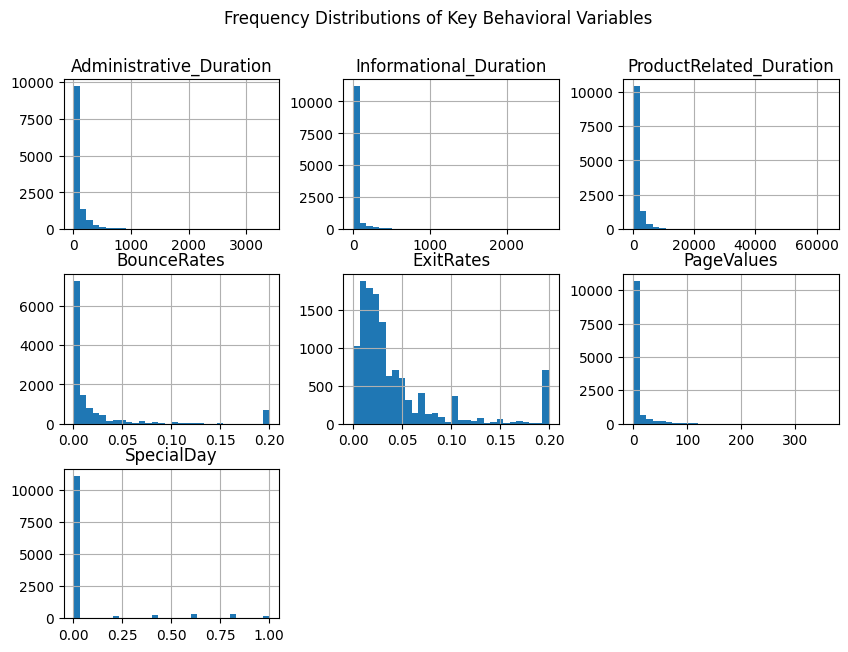

In [53]:
import matplotlib.pyplot as plt

cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

df[cols].hist(figsize=(10, 7), bins=30)
plt.suptitle("Frequency Distributions of Key Behavioral Variables", fontsize=12)
plt.show()

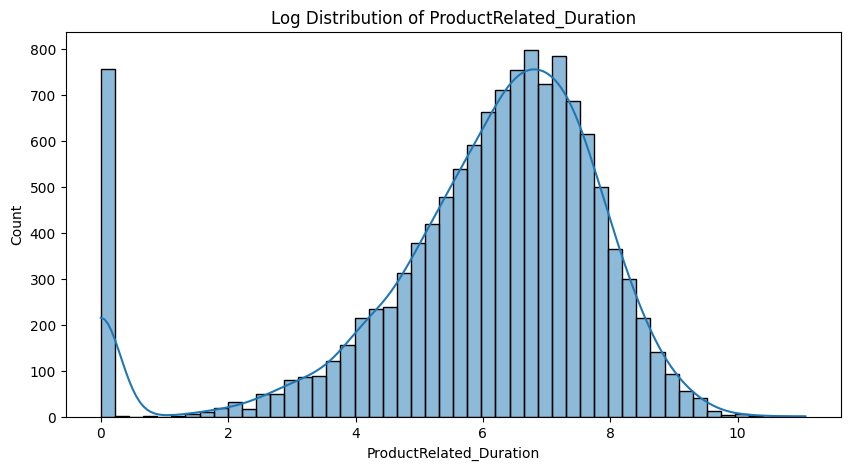

In [54]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['ProductRelated_Duration']), bins=50, kde=True)
plt.title("Log Distribution of ProductRelated_Duration")
plt.show()

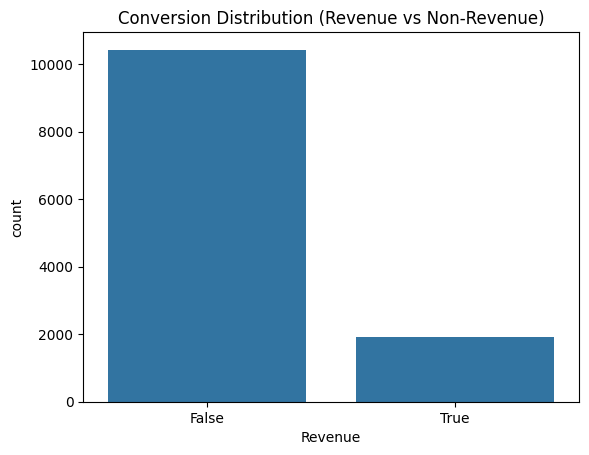

In [55]:
sns.countplot(x='Revenue', data=df)
plt.title("Conversion Distribution (Revenue vs Non-Revenue)")
plt.show()

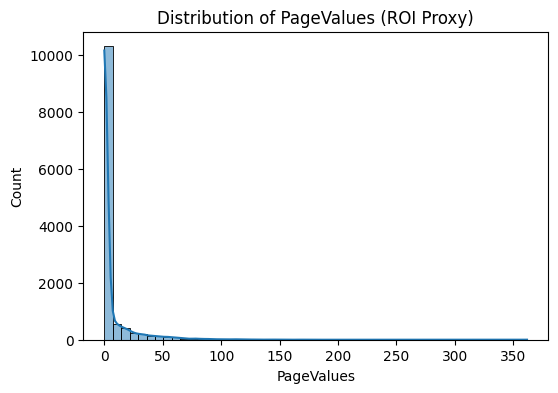

In [56]:
plt.figure(figsize=(6,4))
sns.histplot(df['PageValues'], bins=50, kde=True)
plt.title("Distribution of PageValues (ROI Proxy)")
plt.show()

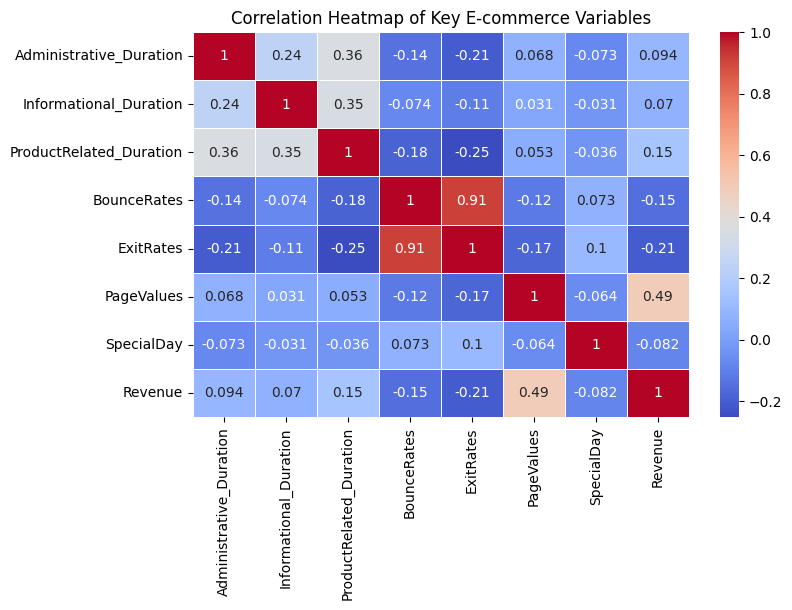

In [57]:
# Select key variables
corr_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Revenue'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Key E-commerce Variables")
plt.show()

In [59]:
print("\nSkewness of numerical variables:")
print(df[num_cols].skew())


Skewness of numerical variables:
Administrative_Duration    5.615719
Informational_Duration     7.579185
ProductRelated_Duration    7.263228
BounceRates                2.947855
ExitRates                  2.148789
PageValues                 6.382964
SpecialDay                 3.302667
dtype: float64
